<a href="https://colab.research.google.com/github/lithikaneelakandan56-ctrl/ml_practice/blob/main/DL/day11_ann_fashion_mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
print("Training data:", X_train.shape)
print("Training labels:", y_train.shape)
print("Testing data:", X_test.shape)
print("Testing labels:", y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data: (60000, 28, 28)
Training labels: (60000,)
Testing data: (10000, 28, 28)
Testing labels: (10000,)


In [3]:
# defining class name
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]
print(class_names)

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


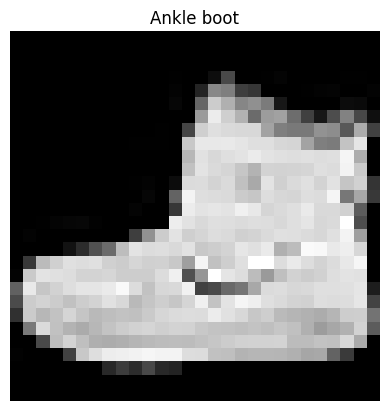

In [4]:
plt.imshow(X_train[0], cmap="gray")
plt.title(class_names[y_train[0]])
plt.axis("off")
plt.show()

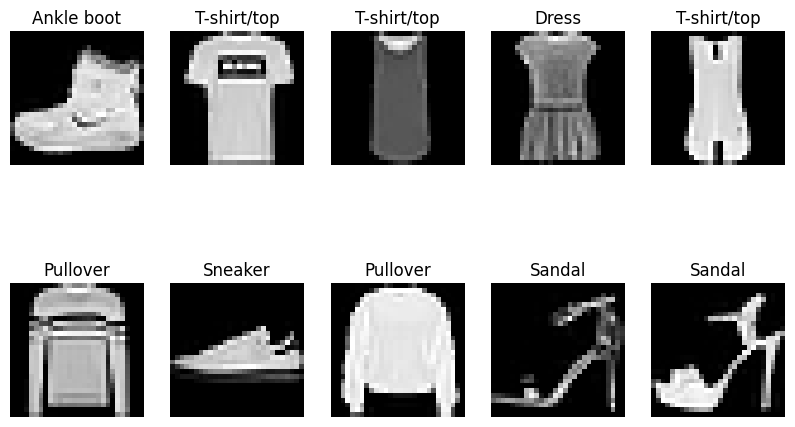

In [5]:
# display multiple images
plt.figure(figsize=(10, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")
plt.show()

In [6]:
print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

Minimum pixel value: 0
Maximum pixel value: 255


In [7]:
# normalize the image
X_train = X_train / 255.0
X_test = X_test / 255.0
print("Minimum:", X_train.min())
print("Maximum:", X_train.max())

Minimum: 0.0
Maximum: 1.0


In [8]:
# build ANN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [11]:
# train the ANN
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8178 - loss: 0.5156 - val_accuracy: 0.8514 - val_loss: 0.4134
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8626 - loss: 0.3789 - val_accuracy: 0.8673 - val_loss: 0.3657
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8742 - loss: 0.3414 - val_accuracy: 0.8773 - val_loss: 0.3391
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8819 - loss: 0.3163 - val_accuracy: 0.8766 - val_loss: 0.3406
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8899 - loss: 0.2972 - val_accuracy: 0.8740 - val_loss: 0.3497
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8936 - loss: 0.2846 - val_accuracy: 0.8844 - val_loss: 0.3283
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8995 - loss: 0.2697 - val_accuracy: 0.8677 - val_loss: 0.3650
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9013 - loss: 0.261

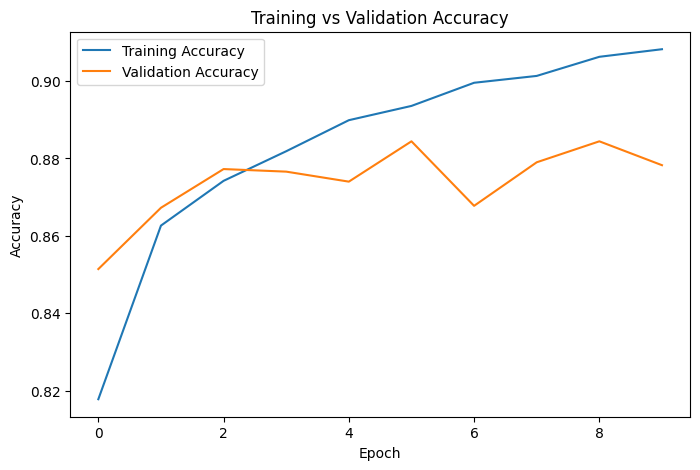

In [12]:
# Plot accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

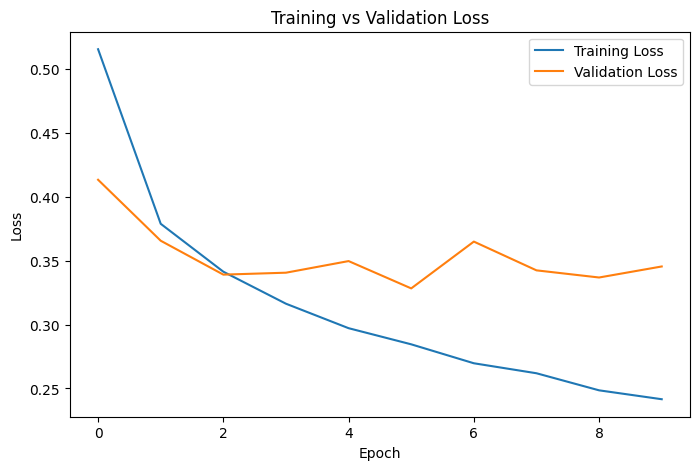

In [13]:
# plot loss
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [14]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)#evaluation

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8708 - loss: 0.3685
Test Loss: 0.36845162510871887
Test Accuracy: 0.8708000183105469


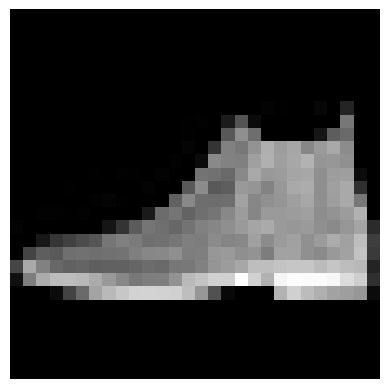

In [15]:
# prediction
sample = X_test[0]
plt.imshow(sample, cmap="gray")
plt.axis("off")
plt.show()

In [16]:
prediction = model.predict(sample.reshape(1, 28, 28))
predicted_class = np.argmax(prediction)
print("Predicted:", class_names[predicted_class])
print("Actual:", class_names[y_test[0]])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
Predicted: Ankle boot
Actual: Ankle boot


In [17]:
print("Prediction probabilities:")
for i in range(10):
    print(
        class_names[i],
        ":",
        round(prediction[0][i] * 100, 2),
        "%"
    )

Prediction probabilities:
T-shirt/top : 0.0 %
Trouser : 0.0 %
Pullover : 0.0 %
Dress : 0.0 %
Coat : 0.0 %
Sandal : 0.04 %
Shirt : 0.0 %
Sneaker : 14.61 %
Bag : 0.0 %
Ankle boot : 85.34 %


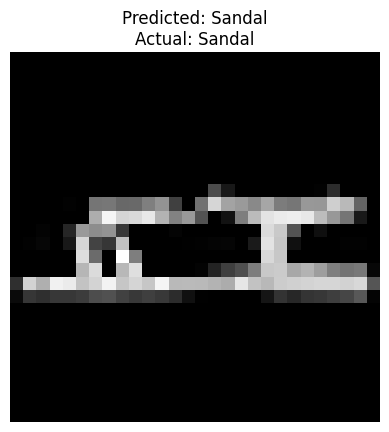

In [18]:
index = np.random.randint(0, len(X_test))

sample = X_test[index]

prediction = model.predict(
    sample.reshape(1, 28, 28),
    verbose=0
)

predicted_class = np.argmax(prediction)

plt.imshow(sample, cmap="gray")
plt.title(
    "Predicted: " + class_names[predicted_class] +
    "\nActual: " + class_names[y_test[index]]
)
plt.axis("off")
plt.show()